In [1]:
!pip install --quiet ta pandas matplotlib seaborn scikit-learn tensorflow streamlit


  DEPRECATION: Building 'ta' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'ta'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import ta

In [5]:
import pandas as pd

df = pd.read_csv("stock_data.csv")
print(df.head())

                        Date     Close      High       Low      Open  \
0  2010-01-04 00:00:00-05:00  6.447413  6.462175  6.398307  6.429940   
1  2010-01-05 00:00:00-05:00  6.458559  6.495012  6.424516  6.465187   
2  2010-01-06 00:00:00-05:00  6.355827  6.484167  6.349199  6.458559   
3  2010-01-07 00:00:00-05:00  6.344075  6.386855  6.297981  6.379323   
4  2010-01-08 00:00:00-05:00  6.386253  6.386856  6.298284  6.335641   

      Volume   EPS       Revenue      ROE        P/E  
0  493729600  6.07  391034994688  1.57413  40.006588  
1  601904800  6.07  391034994688  1.57413  40.006588  
2  552160000  6.07  391034994688  1.57413  40.006588  
3  477131200  6.07  391034994688  1.57413  40.006588  
4  447610800  6.07  391034994688  1.57413  40.006588  


In [6]:
print("Columns:", df.columns.tolist())
display(df.head())


Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'EPS', 'Revenue', 'ROE', 'P/E']


,Date,Close,High,Low,Open,Volume,EPS,Revenue,ROE,P/E
0,2010-01-04 00:00:00-05:00,6.447413,6.462175,6.398307,6.429940,493729600,6.07,391034994688,1.57413,40.006588
1,2010-01-05 00:00:00-05:00,6.458559,6.495012,6.424516,6.465187,601904800,6.07,391034994688,1.57413,40.006588
2,2010-01-06 00:00:00-05:00,6.355827,6.484167,6.349199,6.458559,552160000,6.07,391034994688,1.57413,40.006588
3,2010-01-07 00:00:00-05:00,6.344075,6.386855,6.297981,6.379323,477131200,6.07,391034994688,1.57413,40.006588
4,2010-01-08 00:00:00-05:00,6.386253,6.386856,6.298284,6.335641,447610800,6.07,391034994688,1.57413,40.006588


In [7]:
df.columns = [c.strip() for c in df.columns]
date_candidates = [c for c in df.columns if 'date' in c.lower()]
if len(date_candidates)==0:
    raise ValueError("No 'Date' column found. Please ensure one column is named Date or contains dates.")
date_col = date_candidates[0]
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.sort_values(by=date_col).reset_index(drop=True)


C:\Users\Rajesh Kumar\AppData\Local\Temp\ipykernel_2744\1920745247.py:6: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')


In [8]:
for col in ['Open','High','Low','Close','Volume']:
    if col not in df.columns:
        print(f"Warning: {col} not in CSV. If you have equivalent column, rename it to {col} or modify code.")
display(df[[date_col] + [c for c in ['Open','High','Low','Close','Volume'] if c in df.columns]].head())

,Date,Open,High,Low,Close,Volume
0,2010-01-04 00:00:00-05:00,6.429940,6.462175,6.398307,6.447413,493729600
1,2010-01-05 00:00:00-05:00,6.465187,6.495012,6.424516,6.458559,601904800
2,2010-01-06 00:00:00-05:00,6.458559,6.484167,6.349199,6.355827,552160000
3,2010-01-07 00:00:00-05:00,6.379323,6.386855,6.297981,6.344075,477131200
4,2010-01-08 00:00:00-05:00,6.335641,6.386856,6.298284,6.386253,447610800


In [9]:
df = df.ffill().bfill()
df = df.dropna().reset_index(drop=True)

In [10]:
if 'Close' in df.columns:
    df['ma20'] = df['Close'].rolling(window=20, min_periods=1).mean()
    df['ma50'] = df['Close'].rolling(window=50, min_periods=1).mean()
    # RSI
    df['rsi14'] = ta.momentum.rsi(df['Close'], window=14)
    # MACD
    macd = ta.trend.MACD(df['Close'])
    df['macd'] = macd.macd()
    df['macd_signal'] = macd.macd_signal()
    # Bollinger Bands
    bb = ta.volatility.BollingerBands(df['Close'], window=20, window_dev=2)
    df['bb_high'] = bb.bollinger_hband()
    df['bb_low'] = bb.bollinger_lband()
else:
    print("No 'Close' column to create technical indicators.")

In [11]:
fin_cols = [c for c in ['EPS','EPS (TTM)','Revenue','ROE','P/E','PE'] if c in df.columns]
if len(fin_cols)==0:
    print("No financial indicator columns found in this CSV. If you have a separate financial CSV, upload and merge on Date.")
else:
    print("Found financial columns:", fin_cols)


Found financial columns: ['EPS', 'Revenue', 'ROE', 'P/E']


In [12]:
df['close_lag_1'] = df['Close'].shift(1)
df['close_lag_7'] = df['Close'].shift(7)
df['close_rolling_7_mean'] = df['Close'].rolling(window=7, min_periods=1).mean()
df['close_rolling_30_mean'] = df['Close'].rolling(window=30, min_periods=1).mean()

df = df.dropna().reset_index(drop=True)


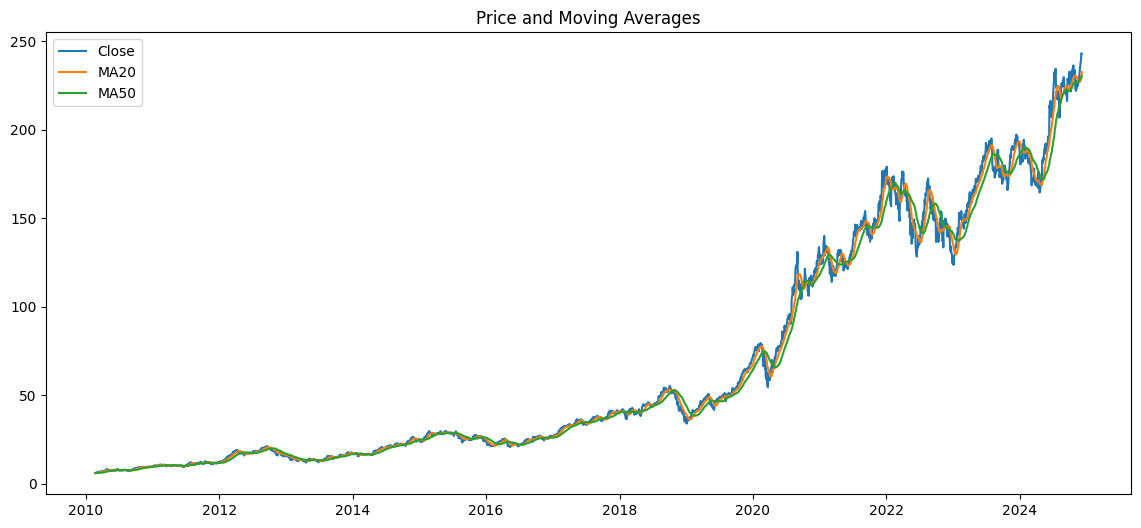

In [13]:
plt.figure(figsize=(14,6))
plt.plot(df[date_col], df['Close'], label='Close')
plt.plot(df[date_col], df['ma20'], label='MA20')
plt.plot(df[date_col], df['ma50'], label='MA50')
plt.legend()
plt.title('Price and Moving Averages')
plt.show()

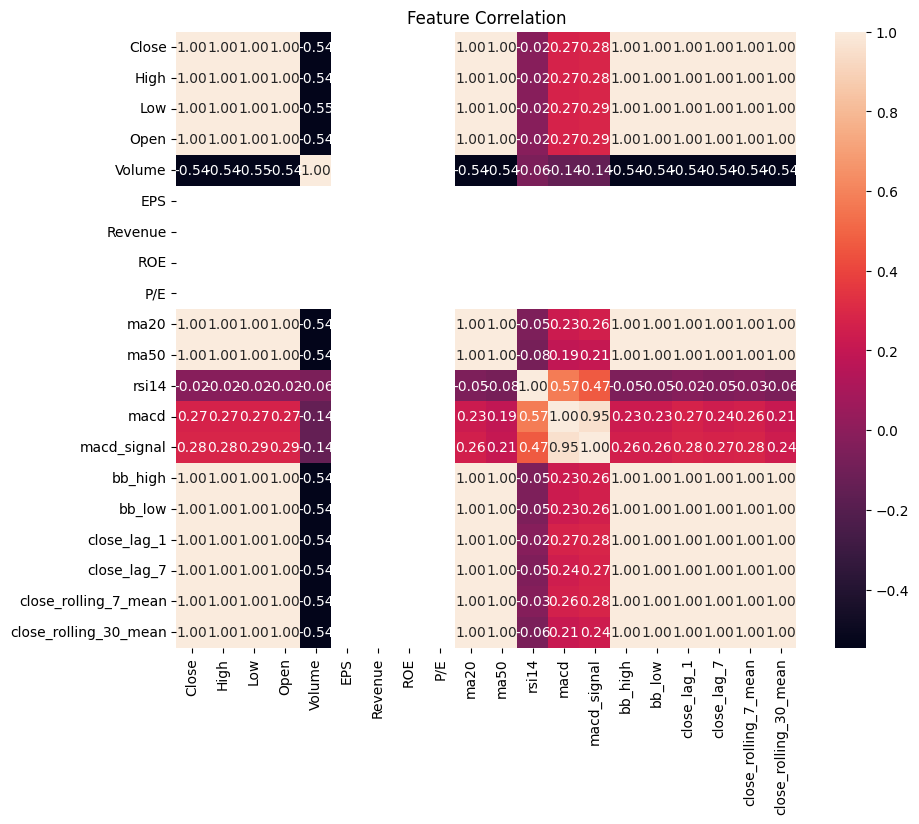

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f")
plt.title("Feature Correlation")
plt.show()


In [15]:
forecast_horizon = 30
df['target'] = df['Close'].shift(-forecast_horizon)
df_model = df.dropna().reset_index(drop=True)

features = list(df_model.select_dtypes(include=[np.number]).columns)
features = [f for f in features if f not in ['target']]
print("Using features:", features)

X = df_model[features]
y = df_model['target']

train_size = int(len(X)*0.7)
val_size = int(len(X)*0.15)
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_val = X.iloc[train_size:train_size+val_size]
y_val = y.iloc[train_size:train_size+val_size]
X_test = X.iloc[train_size+val_size:]
y_test = y.iloc[train_size+val_size:]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

Using features: ['Close', 'High', 'Low', 'Open', 'Volume', 'EPS', 'Revenue', 'ROE', 'P/E', 'ma20', 'ma50', 'rsi14', 'macd', 'macd_signal', 'bb_high', 'bb_low', 'close_lag_1', 'close_lag_7', 'close_rolling_7_mean', 'close_rolling_30_mean']


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_s, y_train)

y_pred_lr = lr.predict(X_test_s)

y_test = np.ravel(y_test)
y_pred_lr = np.ravel(y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / np.maximum(np.abs(y_test), 1e-10))) * 100
r2_lr = r2_score(y_test, y_pred_lr)

print(f"LinearRegression -- RMSE: {rmse_lr:.4f}, MAPE: {mape_lr:.2f}%, R2: {r2_lr:.4f}")


LinearRegression -- RMSE: 14.4254, MAPE: 6.88%, R2: 0.7501


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Ensure both are 1D arrays
y_test = np.ravel(y_test)
y_pred_rf = np.ravel(y_pred_rf)

# Compute metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / np.maximum(np.abs(y_test), 1e-10))) * 100
r2_rf = r2_score(y_test, y_pred_rf)

# Print formatted output
print(f"RandomForest -- RMSE: {rmse_rf:.4f}, MAPE: {mape_rf:.2f}%, R2: {r2_rf:.4f}")


RandomForest -- RMSE: 122.7568, MAPE: 64.90%, R2: -17.0992


In [18]:
sequence_length = 60
def create_sequences(X_arr, y_arr, seq_length):
    Xs, ys = [], []
    for i in range(len(X_arr) - seq_length):
        Xs.append(X_arr[i:(i+seq_length)])
        ys.append(y_arr[i+seq_length])
    return np.array(Xs), np.array(ys)

In [19]:
mm_scaler = MinMaxScaler()
X_all_scaled = mm_scaler.fit_transform(X)

X_seq, y_seq = create_sequences(X_all_scaled, y.values, sequence_length)

In [20]:
n_total = len(X_seq)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
X_seq_train = X_seq[:n_train]; y_seq_train = y_seq[:n_train]
X_seq_val = X_seq[n_train:n_train+n_val]; y_seq_val = y_seq[n_train:n_train+n_val]
X_seq_test = X_seq[n_train+n_val:]; y_seq_test = y_seq[n_train+n_val:]


In [21]:
tf.random.set_seed(42)
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(sequence_length, X_seq.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = model.fit(X_seq_train, y_seq_train, validation_data=(X_seq_val, y_seq_val),
                    epochs=100, batch_size=32, callbacks=[es], verbose=2)

c:\Users\Rajesh Kumar\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,721 (135.63 KB)

 Trainable params: 34,721 (135.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
80/80 - 4s - 55ms/step - loss: 839.5613 - mae: 22.4732 - val_loss: 16459.2227 - val_mae: 126.8932
Epoch 2/100
80/80 - 2s - 29ms/step - loss: 435.9016 - mae: 14.5452 - val_loss: 13688.8232 - val_mae: 115.4621
Epoch 3/100
80/80 - 2s - 28ms/step - loss: 340.1915 - mae: 13.9809 - val_loss: 12792.5488 - val_mae: 111.5133
Epoch 4/100
80/80 - 2s - 30ms/step - loss: 338.6542 - mae: 14.2659 - val_loss: 12759.5908 - val_mae: 111.3654
Epoch 5/100
80/80 - 2s - 28ms/step - loss: 337.2676 - mae: 14.2945 - val_loss: 12751.6553 - val_mae: 111.3298
Epoch 6/100
80/80 - 2s - 26ms/step - loss: 333.4987 - mae: 14.1927 - val_loss: 12753.2080 - val_mae: 111.3368
Epoch 7/100
80/80 - 3s - 31ms/step - loss: 334.4104 - mae: 14.2250 - val_loss: 12743.1777 - val_mae: 111.2917
Epoch 8/100
80/80 - 2s - 27ms/step - loss: 333.0685 - mae: 14.1621 - val_loss: 12742.1709 - val_mae: 111.2872
Epoch 9/100
80/80 - 2s - 29ms/step - loss: 335.7463 - mae: 14.2528 - val_loss: 12723.9551 - val_mae: 111.2054
Epoch 10/1

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


y_pred_lstm = model.predict(X_seq_test).flatten()

y_seq_test = np.ravel(y_seq_test)
y_pred_lstm = np.ravel(y_pred_lstm)

rmse_lstm = np.sqrt(mean_squared_error(y_seq_test, y_pred_lstm))
mape_lstm = np.mean(np.abs((y_seq_test - y_pred_lstm) / np.maximum(np.abs(y_seq_test), 1e-10))) * 100
r2_lstm = r2_score(y_seq_test, y_pred_lstm)

print(f"LSTM -- RMSE: {rmse_lstm:.4f}, MAPE: {mape_lstm:.2f}%, R2: {r2_lstm:.4f}")


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
LSTM -- RMSE: 104.8560, MAPE: 54.28%, R2: -12.3518


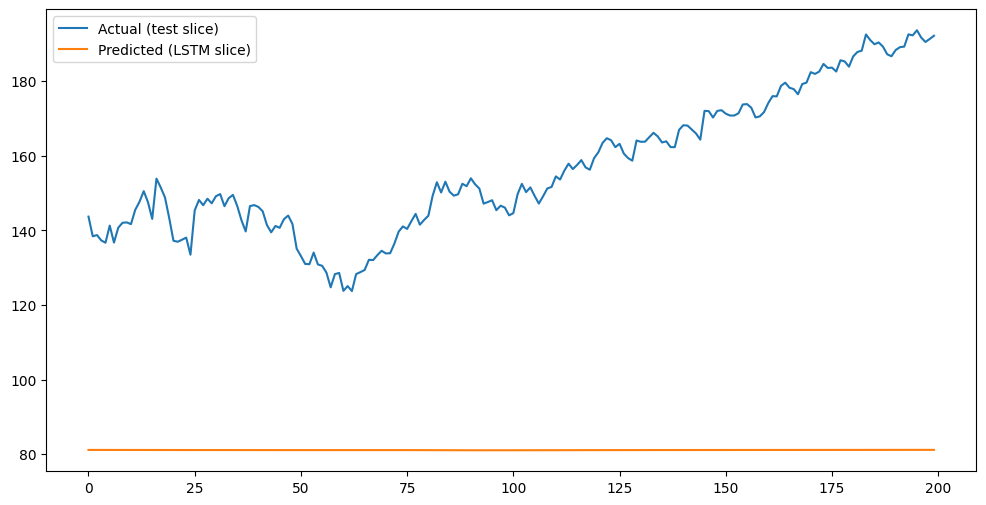

In [23]:
plt.figure(figsize=(12,6))
plt.plot(y_seq_test[:200], label='Actual (test slice)')
plt.plot(y_pred_lstm[:200], label='Predicted (LSTM slice)')
plt.legend()
plt.show()


In [24]:
def forecast_future(df_original, model, mm_scaler, days=180, sequence_length=60):
    df_f = df_original.copy().reset_index(drop=True)
    preds = []
    for i in range(days):
        last_rows = df_f.iloc[-sequence_length:][features]
        last_scaled = mm_scaler.transform(last_rows)
        seq_in = last_scaled.reshape(1, sequence_length, last_scaled.shape[1])
        pred = model.predict(seq_in).flatten()[0]
        preds.append(pred)
        new_row = df_f.iloc[-1].copy()
        new_row['Close'] = pred
        new_row['ma20'] = pd.concat([df_f['Close'], pd.Series([pred])]).rolling(window=20, min_periods=1).mean().iloc[-1]
        new_row['ma50'] = pd.concat([df_f['Close'], pd.Series([pred])]).rolling(window=50, min_periods=1).mean().iloc[-1]
        try:
            new_row[date_col] = df_f[date_col].iloc[-1] + pd.Timedelta(days=1)
        except:
            pass
        df_f = pd.concat([df_f, new_row.to_frame().T], ignore_index=True)
    return preds

future_preds = forecast_future(df_model, model, mm_scaler, days=180, sequence_length=sequence_length)
print("Future predictions (first 10):", future_preds[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

In [25]:
model.save('lstm_stock_model.h5')
import joblib
joblib.dump(scaler, 'scaler_standard.joblib')
joblib.dump(mm_scaler, 'scaler_minmax.joblib')
joblib.dump(rf, 'rf_baseline.joblib')
print("Saved models/scalers to disk.")

Saved models/scalers to disk.


In [27]:
dir


<function dir>